# Banded ETW syntax demo
Timing cells below precompute the dense similarity matrix, so they compare the DP/alignment pass.

In [1]:
import pathlib, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(pathlib.Path.cwd()))
pd.set_option("display.precision", 4)

from simulate_etw_data import simulate_pair
from hellinger_etw import etw_align as etw_full
from hellinger_etw_banded import (
    etw_align_banded,
    euclidean_similarity_matrix,
    make_euclidean_distance_band,
)


In [2]:
pair = simulate_pair(
    80, 80,
    kind="line",
    dim=16,
    seed=4,
    noise=0.005,
    warp_strength=0.05,
    min_spacing=1.0,
)

C = euclidean_similarity_matrix(pair.f_values, pair.g_values, sigma=0.20)
full_band = np.ones(C.shape, dtype=bool)
narrow_band = make_euclidean_distance_band(pair.f_values, pair.g_values, radius=0.10)

full = etw_full(pair.f_values, pair.f_times, pair.g_values, pair.g_times, similarity_matrix=C)
full_via_banded = etw_align_banded(
    pair.f_values, pair.f_times, pair.g_values, pair.g_times,
    similarity_matrix=C,
    band_mask=full_band,
)
banded = etw_align_banded(
    pair.f_values, pair.f_times, pair.g_values, pair.g_times,
    similarity_matrix=C,
    band_mask=narrow_band,
)

pd.DataFrame([
    {"run": "full", "score": full.score, "band_density": 1.0},
    {"run": "banded/full mask", "score": full_via_banded.score, "band_density": 1.0},
    {"run": "banded/narrow distance", "score": banded.score, "band_density": narrow_band.mean()},
])


,run,score,band_density
0,full,0.982,1.0000
1,banded/full mask,0.982,1.0000
2,banded/narrow distance,0.982,0.0942


In [3]:
def time_call(fn, repeats=3):
    times = []
    out = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), out


def distance_quantile_band(X, Y, q):
    d2 = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=2)
    radius = float(np.sqrt(np.quantile(d2, q)))
    return d2 <= radius * radius, radius


def warmup_numba():
    p = simulate_pair(20, 20, kind="line", dim=8, seed=0, min_spacing=1.0)
    C0 = euclidean_similarity_matrix(p.f_values, p.g_values, sigma=0.20)
    etw_full(p.f_values, p.f_times, p.g_values, p.g_times, similarity_matrix=C0)
    etw_align_banded(
        p.f_values, p.f_times, p.g_values, p.g_times,
        similarity_matrix=C0,
        band_mask=np.ones(C0.shape, dtype=bool),
    )

warmup_numba()


In [4]:
def helpful_case(n):
    p = simulate_pair(
        n, n,
        kind="line",
        dim=32,
        seed=1000 + n,
        noise=0.005,
        warp_strength=0.05,
        min_spacing=1.0,
    )
    Cn = euclidean_similarity_matrix(p.f_values, p.g_values, sigma=0.20)
    band = make_euclidean_distance_band(p.f_values, p.g_values, radius=0.10)
    t_full, r_full = time_call(
        lambda: etw_full(p.f_values, p.f_times, p.g_values, p.g_times, similarity_matrix=Cn)
    )
    t_band, r_band = time_call(
        lambda: etw_align_banded(
            p.f_values, p.f_times, p.g_values, p.g_times,
            similarity_matrix=Cn,
            band_mask=band,
        )
    )
    return {
        "n": n,
        "band_density": band.mean(),
        "full_s": t_full,
        "banded_s": t_band,
        "speedup": t_full / t_band,
        "score_gap": r_full.score - r_band.score,
    }

sizes = [80, 120, 180, 260, 360, 500]
help_df = pd.DataFrame([helpful_case(n) for n in sizes])
help_df


,n,band_density,full_s,banded_s,speedup,score_gap
0,80,0.0905,0.0005,0.0002,2.2039,0.0
1,120,0.0883,0.0010,0.0004,2.9357,0.0
2,180,0.0890,0.0022,0.0006,3.6950,0.0
3,260,0.0904,0.0053,0.0016,3.2765,0.0
4,360,0.0898,0.0101,0.0032,3.1666,0.0
5,500,0.0897,0.0218,0.0080,2.7358,0.0


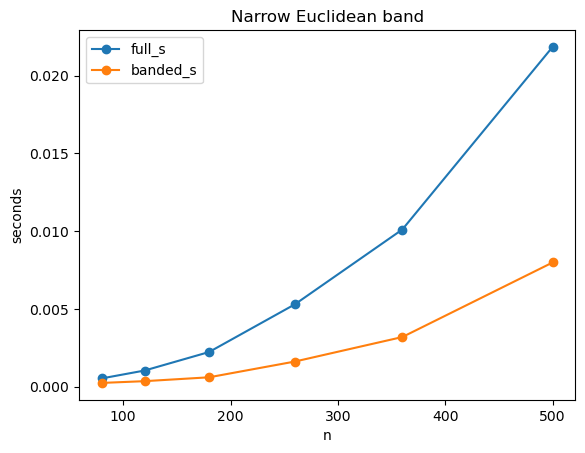

In [5]:
ax = help_df.plot(x="n", y=["full_s", "banded_s"], marker="o")
ax.set_title("Narrow Euclidean band")
ax.set_ylabel("seconds")
plt.show()


In [6]:
def dense_case(n):
    p = simulate_pair(
        n, n,
        kind="integrated_random_walk",
        dim=32,
        seed=2000 + n,
        noise=0.05,
        warp_strength=1.5,
        min_spacing=0.2,
    )
    Cn = euclidean_similarity_matrix(p.f_values, p.g_values, sigma=0.35)
    band, radius = distance_quantile_band(p.f_values, p.g_values, q=0.95)
    t_full, r_full = time_call(
        lambda: etw_full(p.f_values, p.f_times, p.g_values, p.g_times, similarity_matrix=Cn)
    )
    t_band, r_band = time_call(
        lambda: etw_align_banded(
            p.f_values, p.f_times, p.g_values, p.g_times,
            similarity_matrix=Cn,
            band_mask=band,
        )
    )
    return {
        "n": n,
        "band_density": band.mean(),
        "radius": radius,
        "full_s": t_full,
        "banded_s": t_band,
        "speedup": t_full / t_band,
        "score_gap": r_full.score - r_band.score,
    }

dense_df = pd.DataFrame([dense_case(n) for n in sizes])
dense_df


,n,band_density,radius,full_s,banded_s,speedup,score_gap
0,80,0.95,1.3956,0.0012,0.0004,2.7587,0.0
1,120,0.95,1.3308,0.0011,0.0008,1.3865,0.0
2,180,0.95,1.4455,0.0022,0.0017,1.3331,0.0
3,260,0.95,1.4522,0.0044,0.0033,1.3548,0.0
4,360,0.95,1.3877,0.0085,0.0062,1.3665,0.0
5,500,0.95,1.5440,0.0171,0.0126,1.3614,0.0


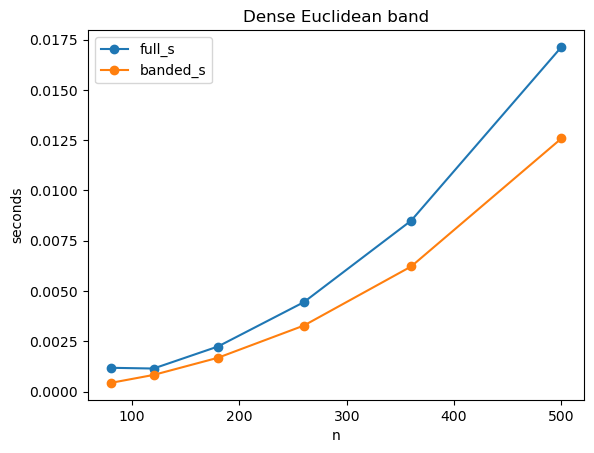

In [7]:
ax = dense_df.plot(x="n", y=["full_s", "banded_s"], marker="o")
ax.set_title("Dense Euclidean band")
ax.set_ylabel("seconds")
plt.show()
